# Redes MLP
O Multilayer Perceptron (MLP) é uma das arquiteturas mais fundamentais de redes neurais, e representa a evolução direta do Perceptron original. Enquanto o Perceptron simples era capaz de resolver apenas problemas linearmente separáveis, o MLP supera essa limitação ao empilhar múltiplas camadas de neurônios artificiais.

Uma rede MLP é composto por três tipos de camadas:
* Camada de entrada: recebe os atributos brutos do dado;
* Camadas ocultas: realizam transformações sucessivas sobre os dados, aprendendo representações intermediárias cada vez mais abstratas;
* Camada de saída: produz a predição final.

Cada neurônio em uma camada está conectado a todos os neurônios da camada seguinte, por isso essas camadas também são chamadas de fully connected ou densas.

O MLP aprende ajustando seus pesos por meio do algoritmo de backpropagation, que aplica a regra da cadeia do cálculo diferencial para propagar o erro da saída de volta até a entrada.

Um estudo teórico sobre redes MLP está disponível em slides. Clique [aqui](#) para acessar os slides.

## Implementação utilizando a Pytorch

Vamos apresentar a implementação de uma rede MLP utilizando a biblioteca `pytorch`. Estudaremos dois casos - MLP aplicado à regressão e MLP aplicada à classificação.

### MLP aplicada à Regressão

Vamos utilizar uma rede MLP para um problema de regressão que visa prever o valor de um imóvel baseado em um conjunto de características desse imóvel.

#### Primeira Implementação - Forma básica

In [1]:
# Importando as bibliotecas básicas
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# ── Configurações de Plotagem ────────────────────────────────────────────────
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 5)

In [3]:
# Carregando o dataset
data = fetch_california_housing()
X = data.data
y = data.target.reshape(-1, 1)

In [4]:
# Visualizando o dataset
df = pd.DataFrame(X, columns=data.feature_names)
df['MedHouseVal'] = y
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [5]:
# Divisão em conjunto de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# Convertendo para tensores do Pytorch
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

In [8]:
# Cria o modelo para a regressão
class MLPRegression(nn.Module):
    def __init__(self, input_size):
        super(MLPRegression, self).__init__()
        self.hidden1 = nn.Linear(input_size, 64)  # Entrada -> Oculta 64
        self.hidden2 = nn.Linear(64, 32)          # Oculta 64 -> Oculta 32
        self.output = nn.Linear(32, 1)            # Oculta 32 -> Saída
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.output(x)
        return x

In [9]:
print(X_train.shape[1])

8


In [10]:
# Criar a instância do modelo
model = MLPRegression(X_train.shape[1])

In [11]:
# Parâmetros de treinamento
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
# Laco de treinamento
epochs = 200
train_loss = np.zeros(epochs)
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Fase Forward
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Fase Backward
    loss.backward()

    # Atualiza os pesos
    optimizer.step()
    train_loss[epoch] = loss.item()

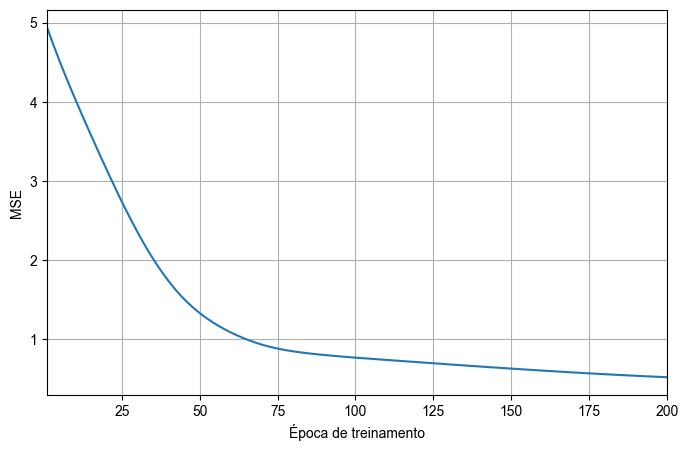

In [13]:
# Visualização da curva de treinamento
plt.figure()
epoch_vector = np.arange(1, epochs+1)
plt.plot(epoch_vector, train_loss)
plt.xlim([1, epochs])
plt.xlabel("Época de treinamento")
plt.ylabel("MSE")
plt.grid()
plt.show()

In [14]:
# Avaliação do modelo
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test)
    r2 = r2_score(y_test.numpy(), predictions.numpy())

print(f"\nMSE Final no Teste: {test_loss.item():.4f}")
print(f"R2: {r2:.4f}")


MSE Final no Teste: 0.5328
R2: 0.5934


#### Segunda implementação - Adicionando os minibatches

Durante o treinamento de uma rede neural, é necessário definir quantos exemplos serão usados para calcular o gradiente e atualizar os pesos a cada iteração. Essa escolha dá origem a três abordagens distintas:
* Batch Gradient Descent (BGD) — usa o dataset inteiro de uma vez;
* Stochastic Gradient Descent (SGD) — usa um único exemplo por vez;
* Mini-batch Gradient Descent — usa um subconjunto de tamanho $b$.

A implementação anterior é um caso do  Batch Gradient Descent (BGD). Por sua vez, o minibatch é essencialmente o equilíbrio entre os dois extremos, e na prática é quase universalmente adotado.

In [15]:
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size = 32, shuffle = True)

In [16]:
# Laco de treinamento
epochs = 50
train_loss = np.zeros(epochs)
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    # Apresenta os minibatches
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        # Fase Forward
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Fase Backward
        loss.backward()

        # Atualiza os pesos
        optimizer.step()
        epoch_loss += loss.item()
    
    # Apresenta o vetor de erros
    train_loss[epoch] = epoch_loss / len(train_loader)

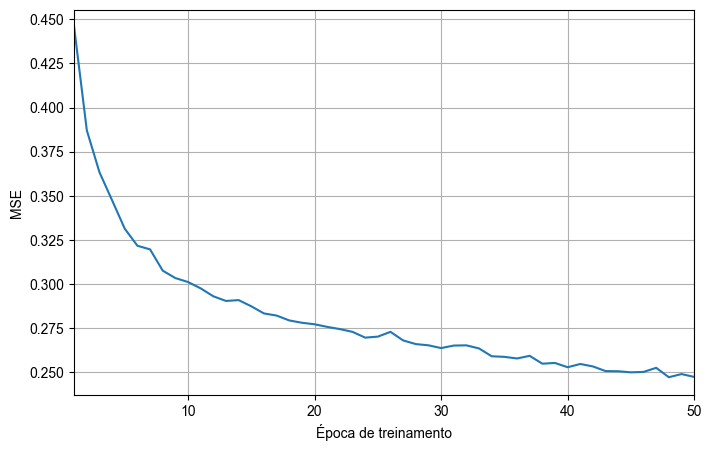

In [17]:
# Visualização da curva de treinamento
plt.figure()
epoch_vector = np.arange(1, epochs+1)
plt.plot(epoch_vector, train_loss)
plt.xlim([1, epochs])
plt.xlabel("Época de treinamento")
plt.ylabel("MSE")
plt.grid()
plt.show()

In [18]:
# Avaliação do modelo
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test)
    r2 = r2_score(y_test.numpy(), predictions.numpy())

print(f"\nMSE Final no Teste: {test_loss.item():.4f}")
print(f"R2: {r2:.4f}")


MSE Final no Teste: 0.2747
R2: 0.7904


#### Terceira implementação - Adicionando o conjunto de validação

Durante o treinamento, o modelo tem acesso direto aos dados de treino — ele os vê repetidamente e ajusta seus pesos para minimizar o erro sobre eles. O problema é que minimizar o erro de treino não é o objetivo final; o objetivo é que o modelo generalize bem para dados novos, nunca vistos.

O conjunto de validação tem como objetivo:
* Detectar Overfitting;
* Guiar o Early Stopping;
* Seleção de Hiperparâmetros.

In [19]:
# Carregando o dataset
data = fetch_california_housing()
X = data.data
y = data.target.reshape(-1, 1)

In [20]:
# Divisão em conjunto de treinamento (70%), validação (15%) e teste (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [21]:
# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [22]:
# Convertendo para tensores do Pytorch
X_train = torch.tensor(X_train, dtype = torch.float32)
X_val = torch.tensor(X_val, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_val = torch.tensor(y_val, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

In [23]:
# Criando os minibatchs
train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size = 32, shuffle = True)

In [24]:
# Criar a instância do modelo
model = MLPRegression(X_train.shape[1])

In [25]:
# Parâmetros de treinamento
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [26]:
# Laco de treinamento
epochs = 50
train_loss = np.zeros(epochs)
val_loss = np.zeros(epochs)

for epoch in range(epochs):
    # ── Fase de treino ──────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    train_loss[epoch] = epoch_train_loss / len(train_loader)

    # ── Fase de validação ───────────────────────────────────────
    model.eval()
    with torch.no_grad():
        val_predictions = model(X_val)
        val_loss[epoch] = criterion(val_predictions, y_val).item()

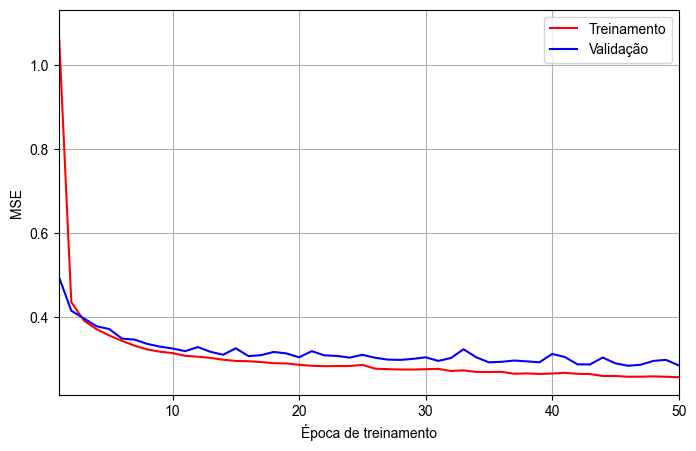

In [27]:
# Visualização da curva de treinamento
epoch_vector = np.arange(1, epochs+1)
plt.figure()
plt.plot(epoch_vector, train_loss, 'r', label = "Treinamento")
plt.plot(epoch_vector, val_loss, 'b', label = "Validação")
plt.xlim([1, epochs])
plt.xlabel("Época de treinamento")
plt.ylabel("MSE")
plt.grid()
plt.legend()
plt.show()

In [28]:
# Avaliação do modelo
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test)
    r2 = r2_score(y_test.numpy(), predictions.numpy())

print(f"\nMSE Final no Teste: {test_loss.item():.4f}")
print(f"R2: {r2:.4f}")


MSE Final no Teste: 0.2463
R2: 0.8137


#### Quarta Implementação - Adicionando a parada antecipada

A ideia por trás da parada antecipada é simples: interromper o treinamento no momento em que o modelo começa a memorizar os dados de treino, antes que o overfitting se instale de forma irreversível. Para isso, ele verifica se o erro de validação aumenta à medida do treinamento.

In [29]:
# Criar a instância do modelo, critério de perda e otimizador
model = MLPRegression(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [30]:
# Treinamento
epochs = 200
patience = 15
best_val_loss = np.inf
best_weights = None

train_loss = []
val_loss = []
stop_epoch = epochs
epochs_no_improve = 0

# Laço de treinamento
for epoch in range(epochs):

    # Treinamento
    model.train()
    epoch_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    train_loss.append(epoch_train_loss / len(train_loader))

    # Validação
    model.eval()
    with torch.no_grad():
        val_predictions = model(X_val)
        val_loss.append(criterion(val_predictions, y_val).item())
    
    # Parada antecipada
    if val_loss[-1] < best_val_loss:
        best_val_loss = val_loss[-1]
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            stop_epoch = epoch + 1
            print(f"Early stopping at epoch {stop_epoch}")
            break

Early stopping at epoch 92


In [31]:
# Restaura os melhores pesos encontrados durante o treinamento
model.load_state_dict(best_weights)

<All keys matched successfully>

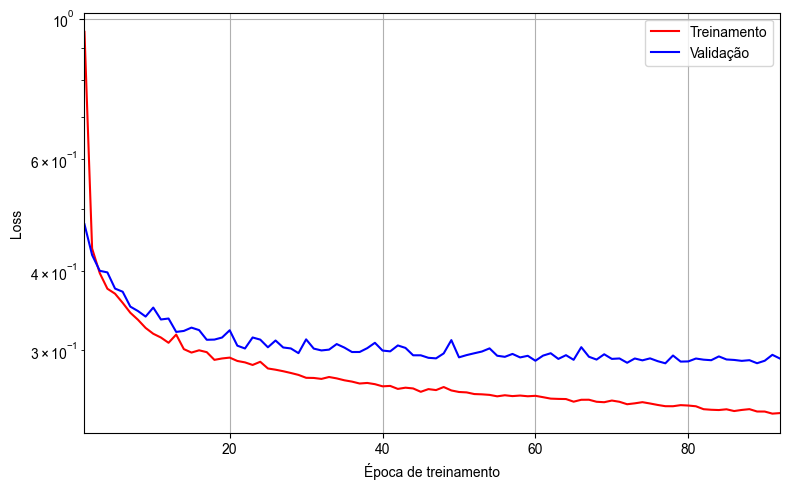

In [32]:
# Plotar a curva de perda de treinamento e validação
epoch_vector = np.arange(1, len(train_loss)+1)
plt.figure()
plt.semilogy(epoch_vector, train_loss, 'r', label = "Treinamento")
plt.semilogy(epoch_vector, val_loss, 'b', label = "Validação")
plt.xlim([1, len(train_loss)])
plt.xlabel("Época de treinamento")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# Avaliação do modelo no conjunto de teste
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test)
r2 = r2_score(y_test.numpy(), predictions.numpy())

print(f"\nMSE Final no Teste: {test_loss.item():.4f}")
print(f"R2: {r2:.4f}")


MSE Final no Teste: 0.2405
R2: 0.8181


### MLP aplicada à classificação

A classificação é uma das tarefas mais naturais para um MLP. Vamos utilizar uma MLP para a classificação de dígitos escritos de forma manual.

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

In [35]:
# Carregando o dataset
digits = load_digits()
X = digits.data
y = digits.target

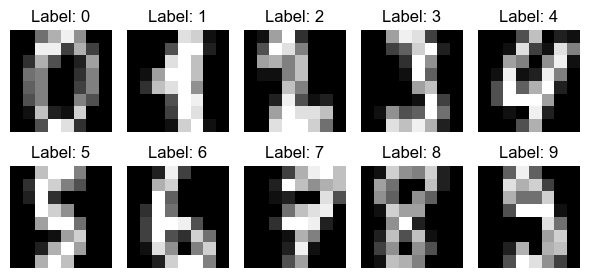

In [38]:
# Visualizado o dataset - digits
fig, axes = plt.subplots(2, 5, figsize=(6, 3))
for digit, ax in enumerate(axes.flat):
    idx = np.random.choice(np.where(y == digit)[0])
    ax.imshow(digits.images[idx], cmap='gray')
    ax.set_title(f"Label: {y[idx]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [39]:
# Divisão em conjunto de treinamento (70%), teste (15%) e validação (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [40]:
# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

In [41]:
# Converter para tensores. Atenção: para problemas com o Pytorch, em classificação, utiliza-se long
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [42]:
# Criando os minibatches
train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size = 32, shuffle = True)

In [43]:
# Criando o modelo para classificação
class DigitsNet(nn.Module):
    def __init__(self, input_size, n_classes):
        super(DigitsNet, self).__init__()
        self.hidden1 = nn.Linear(input_size, 128)   # Entrada -> Oculta 128
        self.hidden2 = nn.Linear(128,64)            # Oculta 128 -> Oculta 64
        self.output = nn.Linear(64, n_classes)      # Oculta 64 -> Saída (classes)
        self.relu = nn.ReLU() 

    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))          
        x = self.output(x)
        return x

In [44]:
# Criando a instância do modelo, critério de perda e otimizador
n_classes = len(torch.unique(y_train))
print(n_classes)

10


In [45]:
X_train.shape[1]

64

In [46]:
model = DigitsNet(input_size=X_train.shape[1], n_classes=n_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [47]:
# Treinamento - já aborda conjunto de validação e parada antecipada
epochs = 200
patience = 15
best_val_loss = np.inf
best_weights = None

train_loss = []
val_loss = []
stop_epoch = epochs
epochs_no_improve = 0

# Laço de treinamento
for epoch in range(epochs):
    # Treinamento 
    model.train()
    epoch_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    train_loss.append(epoch_train_loss / len(train_loader))

    # Validação
    model.eval()
    with torch.no_grad():
        val_predictions = model(X_val)
        val_loss.append(criterion(val_predictions, y_val).item())

    # Early Stopping
    if val_loss[-1] < best_val_loss:
        best_val_loss = val_loss[-1]
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            stop_epoch = epoch + 1
            print(f"Early stopping at epoch {stop_epoch}")
            break

Early stopping at epoch 32


In [48]:
# Restaura os melhores pesos encontrados durante o treinamento
model.load_state_dict(best_weights)

<All keys matched successfully>

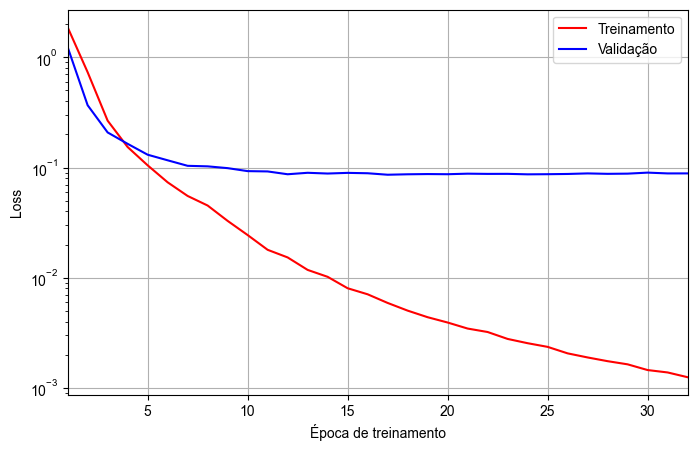

In [49]:
# Plotar a curva de perda de treinamento e validação
epoch_vector = np.arange(1, len(train_loss)+1)
plt.figure()
plt.semilogy(epoch_vector, train_loss, 'r', label = "Treinamento")
plt.semilogy(epoch_vector, val_loss, 'b', label = "Validação")
plt.xlim([1, len(train_loss)])
plt.xlabel("Época de treinamento")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

In [50]:
# Avaliação do modelo
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    predicted = torch.argmax(outputs, dim=1).numpy()

accuracy = accuracy_score(y_test.numpy(), predicted)
cmatrix = confusion_matrix(y_test.numpy(), predicted)
print(f'\nAcurácia Final: {accuracy:.4f}')
print("Matriz de Confusão:")
print(cmatrix)


Acurácia Final: 0.9704
Matriz de Confusão:
[[22  0  0  0  0  0  0  0  0  0]
 [ 0 26  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0]
 [ 0  0  1 19  0  0  0  0  1  0]
 [ 0  0  0  0 31  0  0  0  0  0]
 [ 0  0  0  0  0 36  1  0  0  2]
 [ 0  0  0  0  0  0 30  0  0  0]
 [ 0  0  0  0  0  0  0 27  0  1]
 [ 0  0  0  0  0  1  0  0 17  0]
 [ 0  0  0  0  0  0  0  0  1 34]]


### Utilizando aceleração gráfica

GPUs foram originalmente projetadas para renderização gráfica, mas sua arquitetura — composta por milhares de núcleos menores operando em paralelo — se mostrou extraordinariamente adequada para as operações matemáticas que dominam o aprendizado profundo: multiplicações de matrizes, convoluções e somas vetoriais em larga escala.

CUDA (Compute Unified Device Architecture) é a plataforma da NVIDIA que permite usar a GPU para computação de propósito geral. O PyTorch usa CUDA como backend para todas as operações em GPU, abstraindo sua complexidade:

In [51]:
# Importando as bibliotecas
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

In [52]:
# Verificando se existe um dispositivo CUDA 13
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [53]:
# Carregando o dataset
digits = load_digits()
X = digits.data
y = digits.target

In [54]:
# Divisão em treinamento, validação e teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [55]:
# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

In [56]:
# Converter para tensores
X_train     = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test      = torch.tensor(X_test, dtype=torch.float32).to(device)
X_val       = torch.tensor(X_val, dtype=torch.float32).to(device)
y_train     = torch.tensor(y_train, dtype=torch.long).to(device)
y_test      = torch.tensor(y_test, dtype=torch.long).to(device)
y_val       = torch.tensor(y_val, dtype=torch.long).to(device)

In [57]:
# Criando os minibatches
train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size = 32, shuffle = True)

In [58]:
# Criando o modelo para classificação
class DigitsNet(nn.Module):
    def __init__(self, input_size, n_classes):
        super(DigitsNet, self).__init__()
        self.hidden1 = nn.Linear(input_size, 128)   # Entrada -> Oculta 128
        self.hidden2 = nn.Linear(128,64)            # Oculta 128 -> Oculta 64
        self.output = nn.Linear(64, n_classes)      # Oculta 64 -> Saída (classes)
        self.relu = nn.ReLU() 

    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))          
        x = self.output(x)
        return x

In [59]:
# Criar a instância do modelo, critério de perda e otimizador
n_classes = len(torch.unique(y_train))
model = DigitsNet(input_size=X_train.shape[1], n_classes=n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [60]:
# Treinamento
epochs              = 200
patience            = 15
best_val_loss       = np.inf
best_weights        = None

train_loss          = []
val_loss            = []
stop_epoch          = epochs
epochs_no_improve   = 0

# Laço de treinamento
for epoch in range(epochs):
    # Treinamento 
    model.train()
    epoch_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    train_loss.append(epoch_train_loss / len(train_loader))

    # Validação
    model.eval()
    with torch.no_grad():
        val_predictions = model(X_val)
        val_loss.append(criterion(val_predictions, y_val).item())

    # Early Stopping
    if val_loss[-1] < best_val_loss:
        best_val_loss = val_loss[-1]
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            stop_epoch = epoch + 1
            print(f"Early stopping at epoch {stop_epoch}")
            break

Early stopping at epoch 43


In [61]:
# Restaura os melhores pesos encontrados durante o treinamento
model.load_state_dict(best_weights)

<All keys matched successfully>

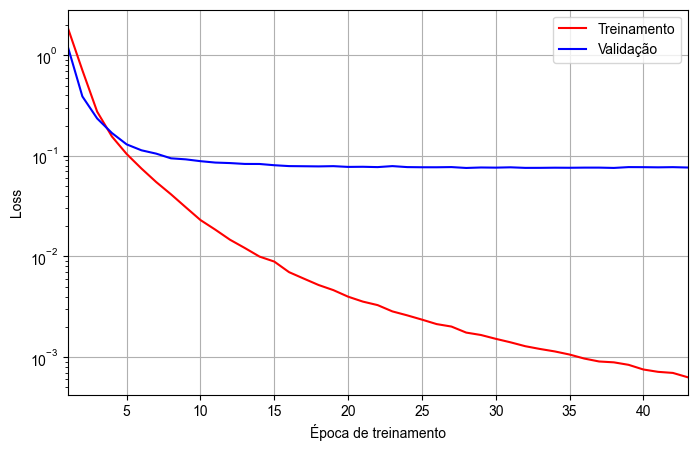

In [62]:
# Plotar a curva de perda de treinamento e validação
epoch_vector = np.arange(1, len(train_loss)+1)
plt.figure()
plt.semilogy(epoch_vector, train_loss, 'r', label = "Treinamento")
plt.semilogy(epoch_vector, val_loss, 'b', label = "Validação")
plt.xlim([1, len(train_loss)])
plt.xlabel("Época de treinamento")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

In [63]:
# Avaliação do modelo no conjunto de teste
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    predicted = torch.argmax(outputs, dim=1).cpu().numpy()

accuracy = accuracy_score(y_test.cpu().numpy(), predicted)
cmatrix = confusion_matrix(y_test.cpu().numpy(), predicted)
print(f'\nAcurácia Final: {accuracy:.4f}')
print("Matriz de Confusão:")
print(cmatrix)


Acurácia Final: 0.9741
Matriz de Confusão:
[[22  0  0  0  0  0  0  0  0  0]
 [ 0 26  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0]
 [ 0  0  1 19  0  0  0  0  1  0]
 [ 0  0  0  0 31  0  0  0  0  0]
 [ 0  1  0  0  0 37  1  0  0  0]
 [ 0  0  0  0  0  0 30  0  0  0]
 [ 0  0  0  0  0  0  0 27  0  1]
 [ 0  0  0  0  0  1  0  0 17  0]
 [ 0  0  0  0  0  0  0  1  0 34]]


## Implementação Manual

Vamos apresentar uma implementação manual de uma rede MLP. Vamos utilizar a rede para um problema de classificação simples de for de íris.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

A função de ativação utilizada será a tangente sigmóide.

In [2]:
# Função de ativação
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Derivada de função de ativação
def sigmoid_deriv(z):
    return np.exp(-z)/((1+np.exp(-z))**2)

In [3]:
# Classe para a rede MLP
class MLP:
    def __init__(self, n_input, n_hidden, n_output=1, lr=0.1):
        self.n_input  = n_input
        self.n_hidden = n_hidden
        self.n_output = n_output
        self.lr       = lr
        self._init_weights()

    # Inicialização de pesos - Inicialização de Xavier
    def _init_weights(self):
        lim1 = np.sqrt(6 / (self.n_input  + self.n_hidden))
        lim2 = np.sqrt(6 / (self.n_hidden + self.n_output))
        self.W1 = np.random.uniform(-lim1, lim1, (self.n_hidden, self.n_input))
        self.b1 = np.zeros(self.n_hidden)
        self.W2 = np.random.uniform(-lim2, lim2, (self.n_output, self.n_hidden))
        self.b2 = np.zeros(self.n_output)

    # Fase forward
    def forward(self, x):
        self._x  = x
        self._u1 = self.W1 @ x - self.b1
        self._a1 = sigmoid(self._u1)
        self._u2 = self.W2 @ self._a1 - self.b2
        self._a2 = sigmoid(self._u2)
        return self._a2

    # Fase backward
    def backward(self, y):
        delta2 = (y - self._a2) * sigmoid_deriv(self._u2)
        delta1 = (self.W2.T @ delta2) * sigmoid_deriv(self._u1)
        self.W2 += self.lr * np.outer(delta2, self._a1)
        self.b2 -= self.lr * delta2
        self.W1 += self.lr * np.outer(delta1, self._x)
        self.b1 -= self.lr * delta1
        return float(0.5 * np.sum((self._a2 - y) ** 2))

    # Função de treinamento
    def train(self, X, Y, epochs=500):
        n = X.shape[0]
        train_loss = []
        for ep in range(1, epochs + 1):
            idx = np.random.permutation(n)
            total = 0.0
            for i in idx:
                self.forward(X[i])
                total += self.backward(Y[i])
            train_loss.append(total / n)
        return train_loss

    # Função para predição
    def predict(self, X):
        return np.array([np.argmax(self.forward(x)) for x in X])

In [4]:
# Carregamento do dataset    
iris = load_iris()
X = iris.data
y = iris.target
Y = np.eye(3)[y]

In [5]:
# Divisão entre conjunto de treinamento e teste
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42, stratify=y
)

In [6]:
# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Cria um modelo com 16 neurônios na camada oculta
model = MLP(n_input=4, n_hidden=16, n_output=3, lr=0.1)

In [12]:
# Aplica a função de treinamento
train_loss = model.train(
    X_train, Y_train, epochs=500
)

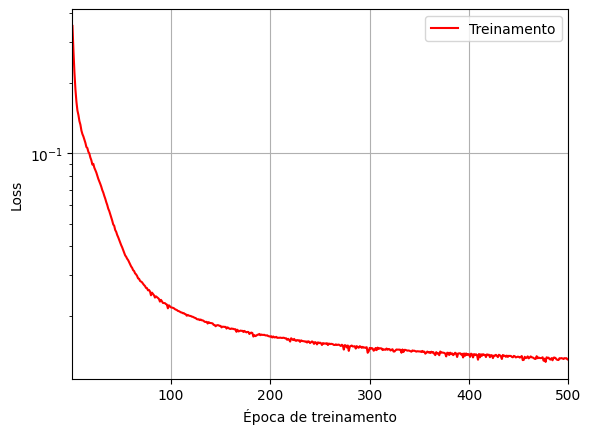

In [13]:
# Apresenta a curva de treinamento
epoch_vector = np.arange(1, len(train_loss)+1)
plt.figure()
plt.semilogy(epoch_vector, train_loss, 'r', label = "Treinamento")
plt.xlim([1, len(train_loss)])
plt.xlabel("Época de treinamento")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

In [14]:
# Calcula a acurácia do modelo
y_pred = model.predict(X_test)
y_true = np.argmax(Y_test,  axis=1)
print(f"Acurácia = {accuracy_score(y_true, y_pred)}")
print("Matriz de Confusão:")
print(confusion_matrix(y_true, y_pred))

Acurácia = 0.9473684210526315
Matriz de Confusão:
[[12  0  0]
 [ 0 12  1]
 [ 0  1 12]]
